In [1]:
################################
###   Imports                ###
################################

import sys, os, subprocess
from pathlib import Path
import numpy as np
import h5py

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from tqdm.auto import tqdm

################################
###   Project Paths          ###
################################

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
PYTHON_DIR = PROJECT_DIR / "python"

DUST_DIR = DATA_DIR / "MWDUST"
IRFS_DIR = DATA_DIR / "IRFs"

PRIOR_ANALYSIS_DIR = DATA_DIR / "prior_analysis"

os.environ["DUST_DIR"] = str(DUST_DIR)

if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))


################################
###   Analysis Imports       ###
################################

import JWST_Line_Model as jlm
from likelihood import build_dimensionless_bin_edges

################################
###   Analysis Setup         ###
################################

SPEED_OF_LIGHT = 299_792.0
REFERENCE_COUPLING = 1e-11

VELOCITY_PARAMETERS = {"v_0": 220.0 / SPEED_OF_LIGHT}

################################
###   Line Model             ###
################################

line_model = jlm.Line_Forward_Model(IRFs_file_loc=str(IRFS_DIR) + os.sep,)
line_model.set_instrument("MIRI")
line_model.set_extinction_law("None")

In [2]:
################################
###   Prior Analysis Data    ###
################################

PRIOR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

JWST_DATA_REPO = (PRIOR_ANALYSIS_DIR / "JWST-data")
MIRI_DATA_PATH = (PRIOR_ANALYSIS_DIR / "miri_data.jld2")
PUBLISHED_BOUND_PATH = (JWST_DATA_REPO / "bounds_miri.csv")

################################
###   Clone Data Repository  ###
################################

if not JWST_DATA_REPO.exists():

    subprocess.run(
        [
            "git clone --depth 1",
            "https://github.com/elenapinetti/JWST-data",
        ],
        cwd=PRIOR_ANALYSIS_DIR,
        check=True,
    )


################################
###   Download MIRI Data     ###
################################

if not MIRI_DATA_PATH.exists():

    subprocess.run(
        [
            "curl -L -o",
            str(MIRI_DATA_PATH),
            (
                "https://github.com/elenapinetti/"
                "JWST-data/releases/download/v1.0/"
                "miri_data.jld2"
            ),
        ],
        check=True,
    )


################################
###   Confirm Inputs         ###
################################

print(f"MIRI data:       {MIRI_DATA_PATH}")
print(f"Published bound: {PUBLISHED_BOUND_PATH}")

MIRI data:       /global/scratch/projects/pc_heptheory/jfoster/DarkJWST/data/prior_analysis/miri_data.jld2
Published bound: /global/scratch/projects/pc_heptheory/jfoster/DarkJWST/data/prior_analysis/JWST-data/bounds_miri.csv


In [3]:
################################
###   Load MIRI Data         ###
################################

def dereference_hdf5(f, value):

    if isinstance(value, h5py.Reference):
        value = f[value][()]

        if isinstance(value, np.ndarray) and value.dtype == np.uint8:
            return value.tobytes().decode()

        if isinstance(value, bytes):
            return value.decode()

        return value

    if isinstance(value, bytes):
        return value.decode()

    return value


with h5py.File(MIRI_DATA_PATH, "r") as f:

    names = np.asarray([
        dereference_hdf5(f, value)
        for value in f["fits_name"][()]
    ])

    wavelength = [
        np.asarray(f[value][()], dtype=np.float64)
        for value in f["wavelength"][()]
    ]

    error = [
        np.asarray(f[value][()], dtype=np.float64)
        for value in f["error"][()]
    ]

    galactic_l = np.asarray(f["l"][()], dtype=np.float64)
    galactic_b = np.asarray(f["b"][()], dtype=np.float64)
    exposure = np.asarray(f["duration"][()], dtype=np.float64)


################################
###   Coordinate Units       ###
################################

galactic_l = np.degrees(galactic_l)
galactic_b = np.degrees(galactic_b)

################################
###   Wavelength Coverage    ###
################################

wavelength_min = np.asarray([values[0] for values in wavelength])
wavelength_max = np.asarray([values[-1]for values in wavelength])

################################
###   Summary                ###
################################

print(f"Spectra:             {len(names)}")
print(f"Total exposure:      {np.sum(exposure) / 3600:,.0f} hr")
print(
    f"Wavelength coverage: "
    f"{np.min(wavelength_min):.2f} -- "
    f"{np.max(wavelength_max):.2f} micron"
)

Spectra:             15419
Total exposure:      3,770 hr
Wavelength coverage: 4.89 -- 28.63 micron


In [4]:
################################
###   Published MIRI Limit   ###
################################

published = np.loadtxt(PUBLISHED_BOUND_PATH, delimiter=",", skiprows=1)
published_mass = published[:, 0]
published_gagg = published[:, 1]

################################
###   Analysis Mass Grid     ###
################################

mass_min = max(np.min(published_mass), 2.0 * line_model.hc / np.max(wavelength_max))
mass_max = min(np.max(published_mass), 2.0 * line_model.hc / np.min(wavelength_min))
masses = np.geomspace(mass_min, mass_max, 50)

published_gagg_interp = np.interp(masses, published_mass, published_gagg)

################################
###   Summary                ###
################################

print(f"Mass range:  {mass_min:.4f} -- {mass_max:.4f} eV")
print(f"Mass points: {len(masses)}")

Mass range:  0.0890 -- 0.5000 eV
Mass points: 50


In [5]:
################################
###   Information Floor      ###
################################

information = np.zeros(len(masses), dtype=np.float64)

for mass_index, mass in enumerate(tqdm(masses, desc="Masses", unit="mass")):

    line_wavelength = 2.0 * line_model.hc / mass
    line_fwhm = line_model.line_FWHM(mass, None, **VELOCITY_PARAMETERS)

    available = np.flatnonzero((wavelength_min < line_wavelength) & (wavelength_max > line_wavelength))

    for dataset_index in tqdm(available, desc=f"Datasets (m = {mass:.3f} eV)", unit="dataset", leave=False):

        wl = wavelength[dataset_index]
        err = error[dataset_index]

        fit_min = line_wavelength - 5.0 * line_fwhm
        fit_max = line_wavelength + 5.0 * line_fwhm
        i0, i1 = np.searchsorted(wl, [fit_min, fit_max])

        # Exclude datasets with only one wavelength bin in the ROI
        if i1 - i0 < 2: continue

        wl_fit = wl[i0:i1]
        err_fit = err[i0:i1]

        valid = np.isfinite(err_fit) & (err_fit > 0.0)

        if not np.any(valid):
            continue

        bin_edges = build_dimensionless_bin_edges(wl_fit, mass, line_model.hc)

        signal = line_model.forward_model(bin_edges, galactic_l[dataset_index], galactic_b[dataset_index],
                                          REFERENCE_COUPLING, mass, None, **VELOCITY_PARAMETERS)

        information[mass_index] += np.sum((signal[valid] / err_fit[valid])**2)

################################
###   Coupling Floor         ###
################################

DELTA_CHI2 = 4.0 # 2503.11753 uses a two sigma limit
g_floor = REFERENCE_COUPLING * (DELTA_CHI2 / np.maximum(information, 1e-300))**0.25

Masses:   0%|          | 0/50 [00:00<?, ?mass/s]

Datasets (m = 0.089 eV):   0%|          | 0/2580 [00:00<?, ?dataset/s]

Datasets (m = 0.092 eV):   0%|          | 0/2597 [00:00<?, ?dataset/s]

Datasets (m = 0.095 eV):   0%|          | 0/2577 [00:00<?, ?dataset/s]

Datasets (m = 0.099 eV):   0%|          | 0/2577 [00:00<?, ?dataset/s]

...

Datasets (m = 0.434 eV):   0%|          | 0/4833 [00:00<?, ?dataset/s]

Datasets (m = 0.450 eV):   0%|          | 0/2865 [00:00<?, ?dataset/s]

Datasets (m = 0.466 eV):   0%|          | 0/2867 [00:00<?, ?dataset/s]

Datasets (m = 0.483 eV):   0%|          | 0/2858 [00:00<?, ?dataset/s]

Datasets (m = 0.500 eV):   0%|          | 0/2816 [00:00<?, ?dataset/s]

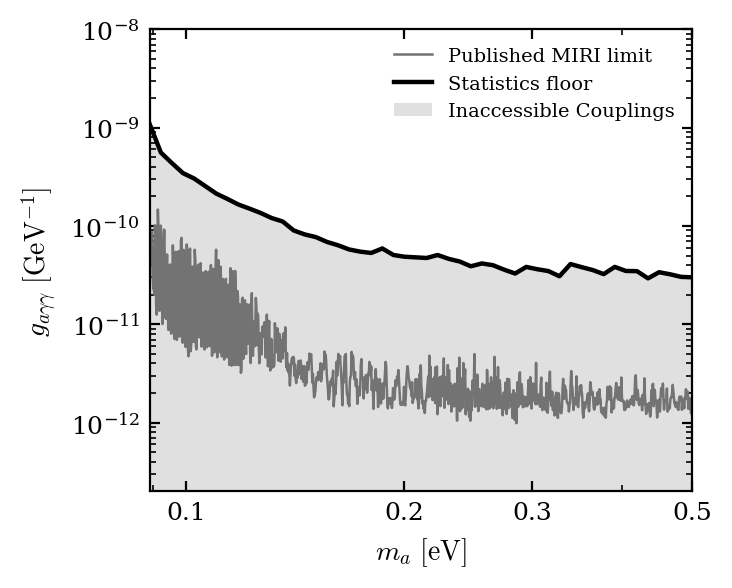

In [6]:
################################
###   Plot Information Floor ###
################################

PLOT_STYLE = {
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
    "axes.labelsize": 10,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}

with plt.rc_context(PLOT_STYLE):

    fig, ax = plt.subplots(figsize=(3.5, 3.0), dpi=200)

    # Published Results from 2503.11753
    ax.plot(published_mass, published_gagg, color="0.45", lw=0.9, label="Published MIRI limit")

    # Information Floor
    ax.plot(masses, g_floor, color="black", lw=1.6, label="Statistics floor")
    ax.fill_between(masses, 1e-13, g_floor, color="0.88", lw=0.0, zorder=0, label = 'Inaccessible Couplings')

    # Formatting
    ax.set_yscale("log")
    ax.set_ylim(2e-13, 1e-8)
    
    ax.set_xscale("log")
    ax.set_xlim(np.min(masses), np.max(masses))
    ax.set_xticks([ 0.1, 0.2, 0.3, 0.5,])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    ax.set_xlabel(r"$m_a\ [\mathrm{eV}]$")
    ax.set_ylabel(r"$g_{a\gamma\gamma}\ [\mathrm{GeV}^{-1}]$")
    ax.legend(loc="upper right",framealpha=1.0, edgecolor="0.8",frameon = False)

    plt.show()